# Семинар по теме «Рабочий стек: `pandas`, `numpy`, `seaborn`, `scipy`, `sklearn`. Продвинутые инструменты для EDA: Sweetviz, YData-Profiling, Polars, DuckDB»

В этом семинаре мы не будем разбирать синтаксис построчно, а расскажем:
- про ключевые приёмы, которые используются в ML-задачах;
- короткие лайфхаки, которые экономят время и помогают в работе;
- типовые баги.

Ещё вспомним особенности разных библиотек и инструментов:
- `pandas`: группировки, Join, Apply;
- `numpy`: Broadcasting, выборки, агрегаты;
- `seaborn`, `matplotlib`, `plotly`: графики для EDA;
- `scipy`: быстрые статистические тесты;
- `sklearn`: Train/Test Split, базовые метрики, Pipeline.

А также посмотрим на продвинутые библиотеки для EDA и анализа данных - Sweetviz, YData-Profiling, Polars, DuckDB (настолько, насколько хватит времени)  




## Источники датасетов


Эти ресурсы помогут в домашних заданиях, проектах и любых ML-задачах.

 [**Kaggle**](https://www.kaggle.com/datasets) — крупнейшее хранилище датасетов, которые часто используются в соревнованиях и CV-проектах.  
> **Примечание.** Требуется регистрация и API-токен для загрузки из ноутбука.

[**OpenML**](https://www.openml.org/search?type=data) — набор датасетов, который можно загрузить прямо через `sklearn.datasets`.




In [ ]:
from sklearn.datasets import fetch_openml
df = fetch_openml(data_id=1461, as_frame=True).frame  # Ames Housing

**`seaborn`** / **`sklearn`**

Некоторые датасеты встроены в популярные библиотеки. Они идеально подходят для EDA, демонстраций и быстрых экспериментов.




In [ ]:
import seaborn as sns
penguins = sns.load_dataset("penguins")       # Пингвины
diamonds = sns.load_dataset("diamonds")       # Бриллианты
mpg = sns.load_dataset("mpg")                 # Машины

In [ ]:
from sklearn.datasets import fetch_california_housing
df = fetch_california_housing(as_frame=True).frame  # Числовые признаки, задача регрессии

Датасет также можно загрузить напрямую по ссылке.

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

## Приёмы в `pandas`

<!-- Pandas — шлифуем приёмы -->

### Структура DataFrame

> `pandas.DataFrame` — это набор объектов `Series`, выровненных по общему индексу.

Каждая колонка в датафрейме — это отдельный `pandas.Series`, у которого есть:
- значения — данные в колонке;
- общий индекс — идентификаторы строк (обычно числовые);
- имя — название `Series` = название колонки;
- тип данных (`dtype`), определяющий поведение операций.

Визуально `DataFrame` выглядит как таблица, но логически — это словарь `Series`, где ключи — названия колонок, а значения — `Series` (см. рисунок 1).





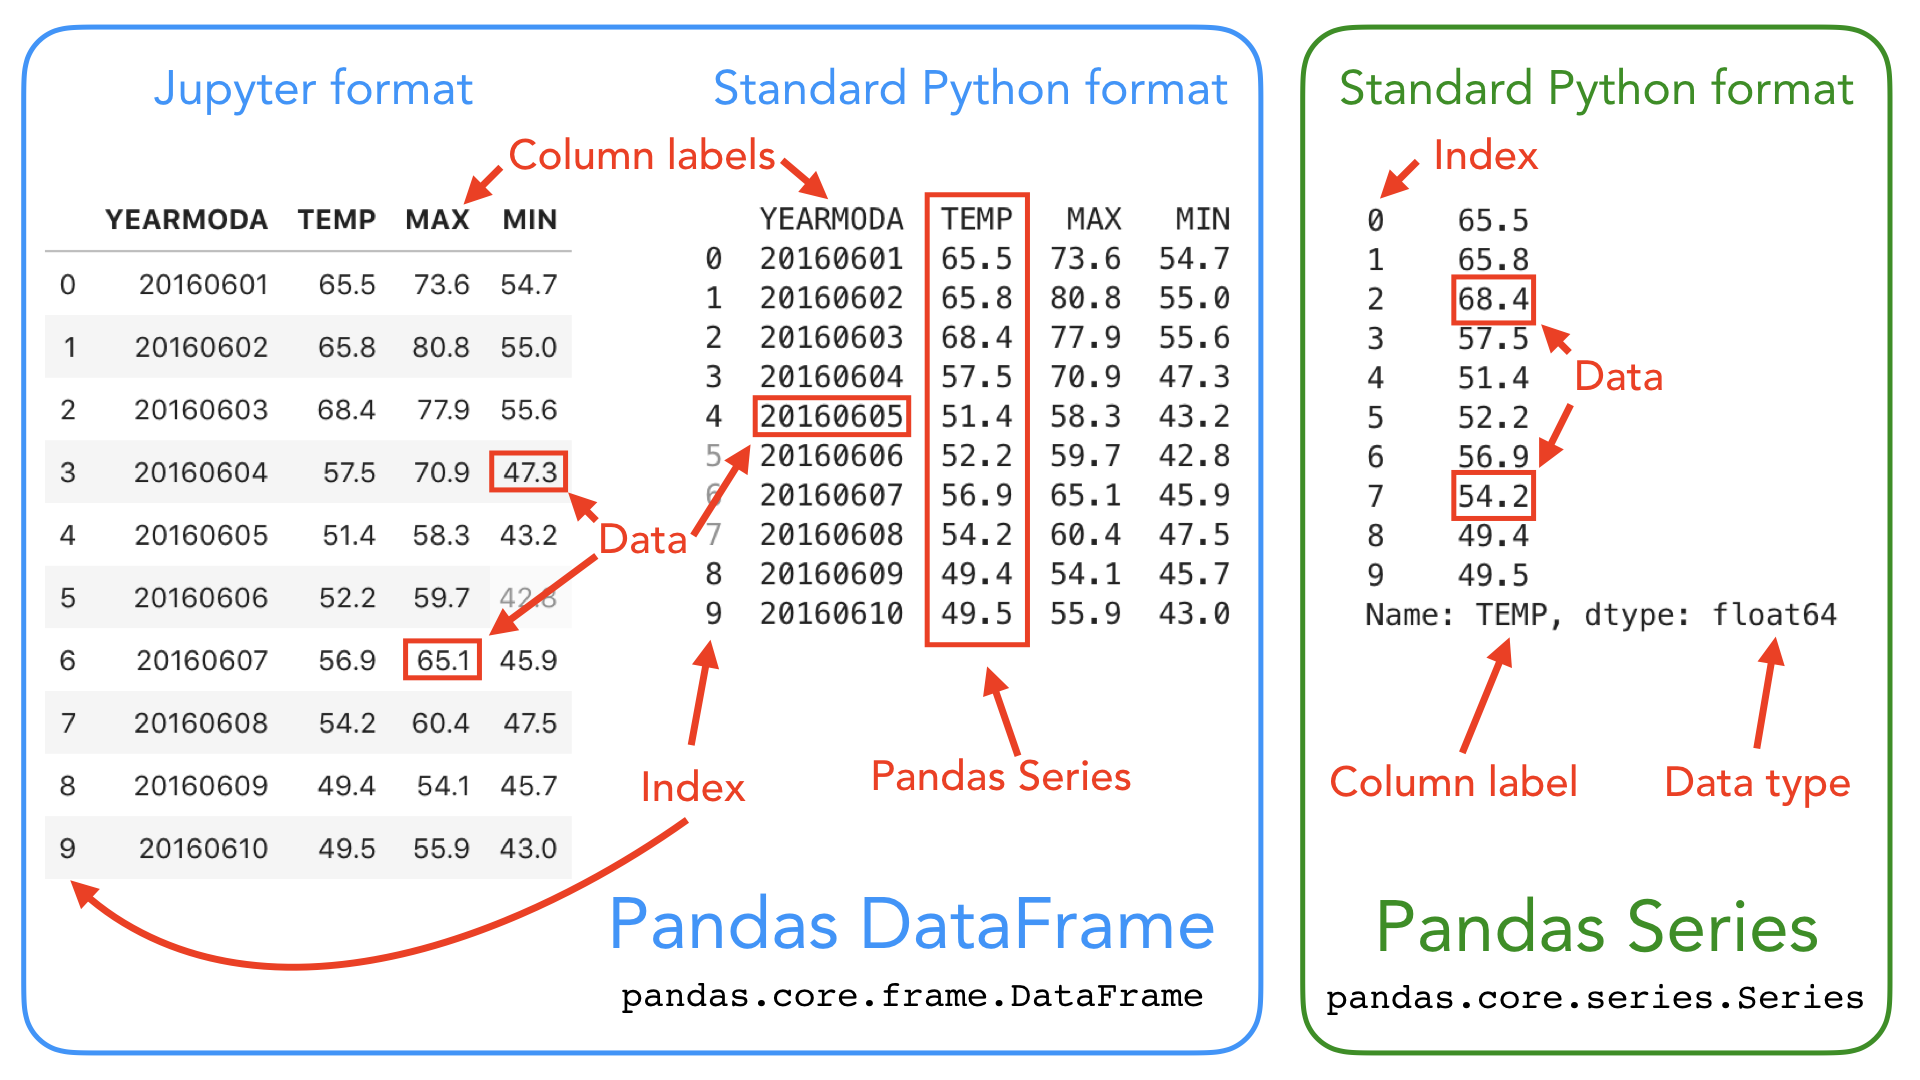

*Рисунок 1. Слева — весь `DataFrame`, справа — одна колонка (`Series`), например `TEMP`. Источник: https://ya.ru/images/search?img_url=https%3A%2F%2Fgeo-python.github.io%2Fsite%2F_images%2Fpandas-structures-annotated.png&lr=213&pos=3&rpt=simage&text=pandas%20dataframe*



> **Важно.** Многие методы (`.loc`, `.iloc`, `.apply`, `.values`) работают по-разному для `DataFrame` и `Series`.

### Основные функции `pandas`


Загрузим датасет `penguins` из `seaborn`.

In [ ]:
import seaborn as sns

penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


 ## Задание 1

Реши базовые аналитические задачи.

1. Сколько пропущенных значений в каждой колонке?
2. Какие уникальные значения принимает колонка species и сколько их?
3. Найди среднюю массу тела (`body_mass_g`) для каждого вида (`species`) пингвинов.
4. Создай колонку `bmi_approx` = масса тела / длина ласты и найди 5 самых «тяжёлых» пингвинов по этой метрике.

In [ ]:
# Твой код здесь

Вспомним основные функции, которые будут нам часто встречаться — это базовый инструментарий для работы в pandas:

In [ ]:
df = sns.load_dataset("penguins")

# --- Индексация и фильтрация ---
df.head()                                              # Первые строки таблицы
df.loc[0, "bill_length_mm"]                            # Доступ по метке строки и колонке
df.iloc[0, 2]                                          # Доступ по позиции
df[df["body_mass_g"] > 4000]                          # Фильтрация по условию
df.loc[df["sex"] == "Male", ["body_mass_g"]]          # Фильтрация + выбор колонки
df.iloc[1:4, [0, 2]]                                   # Срез строк и колонок по индексам

# --- Группировки ---
df.groupby("species")["body_mass_g"].mean()           # Средняя масса по видам
df.groupby(["species", "sex"])["body_mass_g"].agg(["mean", "std"])  # Среднее и std по группам
df.groupby("island")["sex"].value_counts(normalize=True)  # Доли полов по островам
df["z_mass"] = df.groupby("species")["body_mass_g"].transform(      # Нормировка внутри вида
    lambda x: (x - x.mean()) / x.std()
)

# --- Пропуски ---
df.isna().sum()                                        # Число пропусков по колонкам
df.dropna(subset=["bill_length_mm"])                   # Удалить строки с NaN в колонке
df["bill_length_mm"].fillna(df["bill_length_mm"].mean(), inplace=True)  # Замена средним

# --- Объединения и сводные ---
left = pd.DataFrame({"species": ["Adelie", "Chinstrap"], "flag": [1, 0]})
df.merge(left, on="species", how="left", validate="many_to_one")        # Объединение с проверкой
df.pivot_table(index="species", columns="sex", values="body_mass_g", aggfunc="mean")  # Средняя масса по виду и полу

# --- Условия и вычисления ---
df["big_male"] = df.apply(                                # Логическая переменная: крупный самец
    lambda r: r["body_mass_g"] > 5000 and r["sex"] == "Male", axis=1
)
df.query("bill_length_mm > 45 and sex == 'Female'")       # Читаемая фильтрация
df["bill_cleared"] = df["bill_length_mm"].mask(df["bill_length_mm"] < 40, pd.NA)  # Обнуление «коротких» клювов

# --- Оптимизация и сортировки ---
df["sex"] = df["sex"].astype("category")                  # Экономия памяти (категориальный тип)
df.sort_values("flipper_length_mm", ascending=False)      # Сортировка по длине плавника
df["rank"] = df["body_mass_g"].rank(ascending=False)      # Ранжирование по массе

## 5 рабочих приёмов в `numpy`


В задачах ML мы редко пишем код на `numpy`. Всё происходит через `pandas`, `sklearn`, `catboost`, `xgboost`.


Но почти всё «под капотом» — на `numpy`: массивы, матрицы, арифметика, трансформации.

А если ты пойдёшь в Deep Learning, `numpy` понадобится для обработки данных, токенизации, нормализации, пайплайнов и даже для самодельных Forward/Backward-проходов.

В этой теме мы не будем повторять `ndarray` и `reshape(1, -1)`.  
Вместо этого покажем 5 приёмов, которые реально помогают в работе.


In [ ]:
import numpy as np

# --- Что такое ndarray (база NumPy) ---
a = np.array([[1, 2, 3], [4, 5, 6]])   # Двумерный массив
print("shape:", a.shape)              # (2, 3) — 2 строки, 3 колонки
print("dtype:", a.dtype)              # Тип данных внутри (int32, float64 и так далее)
print("ndim:", a.ndim)                # Число осей (в данном случае 2)

# --- 1. Генерация случайных данных (например, для тестов или синтетики) ---
X = np.random.randn(100, 3)    # 100 объектов, 3 признака
y = X @ np.array([1.5, -2, 0.7]) + np.random.randn(100) * 0.1  # Линейная модель + шум

# --- 2. Быстрая фильтрация: np.where ---
y_bin = np.where(y > 0, 1, 0)  # Превращаем в бинарную метку

# --- 3. Перцентили и квантильные отсечки ---
np.percentile(y, [5, 50, 95])

# --- 4. argsort и top-K-отбор ---
top3_idx = np.argsort(y)[-3:]         # Индексы трёх самых больших значений
top3_values = y[top3_idx]

# --- 5. Векторные маски и булева логика ---
mask = (X[:, 0] > 0) & (X[:, 1] < 1)  # Логическая маска по двум признакам
X_filtered = X[mask]


## EDA-графики в `matplotlib`, `seaborn`, `plotly`

Для визуализации EDA-графиков чаще всего используют библиотеки `matplotlib`, `seaborn` и `plotly`.

`matplotlib` — низкоуровневая библиотека для построения графиков в Python. Позволяет детально контролировать внешний вид графиков, но требует больше кода.
Документация Matplotlib: https://matplotlib.org/stable/users/index.html.

`seaborn` — высокоуровневая надстройка над matplotlib, оптимизированная под EDA и работу с DataFrame. Упрощает построение типичных графиков, автоматически применяет красивые стили и хорошо работает с `groupby`-, `categorical`- и `numeric`-переменными.
Документация Seaborn: https://seaborn.pydata.org/.

`plotly` — библиотека для создания интерактивных графиков.
Поддерживает зум, наведение, выборки, сохранение картинок, интерактивные легенды и фильтры без лишнего кода.
Идеально подходит для EDA в ноутбуке, презентаций и построения дашбордов.
В `plotly.express` большинство графиков строится одной строкой, а вся стилизация происходит автоматически.
Документация `plotly.express`: https://plotly.com/python/plotly-express/.

В 90% задач EDA Seaborn предпочтительнее: она проще, аккуратнее и требует меньше кода.
Для кастомизации и сложных донастроек визуализаций Seaborn всё равно использует `matplotlib.pyplot` «под капотом» — так что полезно уметь и то, и другое.

Проведём первичный визуальный анализ данных по датасету «Пингвины» с помощью разных библиотек и затем сравним их.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем датасет
df = sns.load_dataset("penguins").dropna()  # Убираем NaN для чистоты

# Настраиваем цветовую палитру
species = df["species"].unique()
palette = dict(zip(species, sns.color_palette("Set2", len(species))))

# Создаём фигуру
plt.figure(figsize=(10, 6))

# Рисуем точки по видам пингвинов
for sp in species:
    sub = df[df["species"] == sp]
    plt.scatter(
        sub["bill_length_mm"],
        sub["flipper_length_mm"],
        label=sp,
        s=60,
        alpha=0.7,
        c=[palette[sp]]
    )

# Добавляем подписи и легенду
plt.title("Penguins: Bill Length vs Flipper Length", fontsize=14)
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.legend(title="Species")
plt.grid(True)
plt.tight_layout()

# Сохраняем график (опционально)
plt.savefig("penguins_scatter.png", dpi=300)
plt.show()

In [ ]:
import seaborn as sns

# Один вызов = полноценный график
sns.pairplot(sns.load_dataset("penguins").dropna(), hue="species")

In [ ]:
# Seaborn + matplotlib: несколько EDA-графиков в один ряд

import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins").dropna()
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Scatterplot
sns.scatterplot(
    data=df, x="bill_length_mm", y="flipper_length_mm",
    hue="species", palette="Set2", s=70, alpha=0.8, ax=axes[0]
)
axes[0].set_title("Scatter: клюв vs плавник")
axes[0].set_xlabel("Bill length (mm)")
axes[0].set_ylabel("Flipper length (mm)")

# --- Boxplot (добавляем hue = species для соответствия palette)
sns.boxplot(
    data=df, x="species", y="body_mass_g",
    hue="species", palette="Set2", ax=axes[1], legend=False
)
axes[1].set_title("Boxplot: масса по видам")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Body mass (g)")

# --- Countplot (аналогично hue = island)
sns.countplot(
    data=df, x="island",
    hue="island", palette="Set2", ax=axes[2], legend=False
)
axes[2].set_title("Count: количество по островам")
axes[2].set_xlabel("Island")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import seaborn as sns

# Загружаем и чистим данные
df = sns.load_dataset("penguins").dropna()

# Строим интерактивный Scatterplot
fig = px.scatter(
    df,
    x="bill_length_mm",
    y="flipper_length_mm",
    color="species",
    symbol="sex",  # Добавим маркировку по полу
    size="body_mass_g",  # Размер точки — по массе
    hover_data=["island", "body_mass_g"],  # Что показывать при наведении
    title="Penguins: клюв vs плавник (интерактивно)",
    labels={
        "bill_length_mm": "Bill Length (mm)",
        "flipper_length_mm": "Flipper Length (mm)",
        "body_mass_g": "Body Mass (g)",
        "species": "Species",
        "sex": "Sex"
    },
    template="simple_white"
)

fig.update_layout(height=500)
fig.show()

## Статистический анализ в `scipy`

`scipy` — большая библиотека научных инструментов.

В задачах анализа данных чаще всего используют модуль `scipy.stats`. Он включает десятки готовых функций для сравнения групп, анализа распределений, генерации случайных данных, расчёта расстояний и оптимизации.

Документация Scipy Stats: https://docs.scipy.org/doc/scipy.

Список всех подмодулей: https://docs.scipy.org/doc/scipy/tutorial/stats.html.

---

**Ключевые функции `scipy.stats`**

| Задача                                         | Функция                             | Пример прикладной задачи                                 |
|------------------------------------------------|--------------------------------------|----------------------------------------------------------|
| Сравнить средние данные двух групп                    | `stats.ttest_ind(a, b)`              | Кто тяжелее: самцы или самки пингвинов?                  |
| Оценить линейную или ранговую корреляцию       | `stats.pearsonr(x, y)`<br>`stats.spearmanr(x, y)` | Связаны ли длины клюва и плавника?                      |
| Проверить, нормально ли распределены данные    | `stats.normaltest(x)`                | Можно ли применять t-тест к длине клюва?                 |
| Преобразовать данные в z-оценки                | `stats.zscore(x)`                    | Насколько вес конкретного пингвина выбивается из нормы?  |
| Сгенерировать случайные значения из распределения | `stats.norm.rvs(...)`             | Сымитировать веса новых пингвинов                        |
| Посчитать плотность распределения              | `stats.norm.pdf(x, loc, scale)`      | Нарисовать нормальную кривую поверх гистограммы          |
| Посчитать расстояния между объектами           | `cdist(X1, X2, metric="euclidean")`  | Насколько похожи два пингвина по признакам?              |

Снова используем датасет «Пингвины» и посмотрим, что можно исследовать с модулем `scipy.stats`.

In [ ]:
from scipy import stats
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
from scipy.signal import savgol_filter
import pandas as pd

df = sns.load_dataset("penguins").dropna()

# --- Статистика ---

# t-тест: сравнение массы самцов и самок
stats.ttest_ind(
    df[df["sex"] == "Male"]["body_mass_g"],
    df[df["sex"] == "Female"]["body_mass_g"],
    equal_var=False
)

# Корреляции между длиной клюва и длиной плавника
stats.pearsonr(df["bill_length_mm"], df["flipper_length_mm"])
stats.spearmanr(df["bill_length_mm"], df["flipper_length_mm"])

# Проверка на нормальность массы тела
stats.normaltest(df["body_mass_g"])

# Стандартизация признака
df["z_mass"] = stats.zscore(df["body_mass_g"])

# --- Распределения ---

# Плотность нормального распределения для массы
x = np.linspace(3000, 5000, 100)
pdf = stats.norm.pdf(x, loc=df["body_mass_g"].mean(), scale=df["body_mass_g"].std())

# Генерация случайной массы тела (симуляция)
sim_mass = stats.norm.rvs(loc=4000, scale=300, size=5)

# --- Расстояния ---

# Косинусные расстояния между пингвинами по 2 признакам
X = df[["bill_length_mm", "flipper_length_mm"]].to_numpy()
cdist(X[:5], X[:5], metric="cosine")

# --- Оптимизация ---

# Минимизация простой квадратичной функции
fun = lambda x: (x[0] - 50)**2 + (x[1] - 200)**2
minimize(fun, x0=[0, 0])

# --- Сглаживание ---

# Сглаживаем отсортированные массы тела
mass_sorted = np.sort(df["body_mass_g"].to_numpy())
mass_smoothed = savgol_filter(mass_sorted, window_length=11, polyorder=2)

## Задание 2
Ответь на вопросы:
1. У какого вида пингвинов клюв длиннее?
2. Насколько эта разница значима?

In [ ]:
# Твой код здесь

## sklearn — метрики и разбиения

Теперь вспомним базовый функционал sklearn для работы с данными и обучения простых моделей.

In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Загрузка данных
df = sns.load_dataset("penguins")
df = df.dropna()  # Для простоты

# Признаки и целевая переменная
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = df["species"]

# Кодирование целевой переменной
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Предобработка: масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на обучающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, stratify=y_encoded, random_state=42)

# Обучение модели
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Предсказания и метрики
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# Визуализация матрицы
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)
plt.show()

# Кросс-валидация
cv_scores = cross_val_score(model, X_scaled, y_encoded, cv=StratifiedKFold(n_splits=5))
print("CV accuracy:", cv_scores.mean(), "±", cv_scores.std())

# Permutation Importance
r = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=0)
for name, imp in zip(X.columns, r.importances_mean):
    print(f"{name}: {imp:.4f}")

Всё, что мы сделали выше — масштабирование, обучение, предсказание — можно объединить в единый Pipeline.

In [ ]:
from sklearn.pipeline import make_pipeline
model = make_pipeline(StandardScaler(), LogisticRegression())
model.fit(X_train, y_train)

Это удобно: в одном объекте собрана вся цепочка действий с данными.
> **Примечание.** Подробно разберём пайплайны
 позже в курсе. Ты научишься:
 > - комбинировать числовые и категориальные признаки;
 > - подбирать гиперпараметры, сохранять модели.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

# Загружаем данные
X, y = load_iris(return_X_y=True)

# Делим
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Собираем Pipeline: масштабирование + логрегрессия
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=300)
)

# Обучаем и оцениваем
model.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

# Продвинутые инструменты для EDA: Sweetviz, YData-Profiling, Polars, DuckDB

 А теперь изучим специальные инструменты, которые упрощают работу по первичному анализу данных (Exploratory Data Analysis). С ними работать быстрее и удобнее, чем писать каждый раз однотипный код на обычном pandas.

Инструменты:
- Sweetviz — автоматический отчёт;  
- YData-Profiling — детальная статистика;  
- Polars — быстрый аналог pandas;  
- DuckDB — SQL прямо в ноутбуке.  

Для примера возьмём датасет California Housing (sklearn). Это классический датасет из `sklearn`, собранный из данных о переписи населения Калифорнии 1990 года.  
Каждая строка соответствует району (district) в Калифорнии, а признаки описывают социально-экономические и географические характеристики этого района.  

**Признаки**
- `MedInc` — медианный доход жителей района (в десятках тысяч $).  
- `HouseAge` — медианный возраст домов в районе.  
- `AveRooms` — среднее число комнат в доме.  
- `AveBedrms` — среднее число спален в доме.  
- `Population` — население района.  
- `AveOccup` — среднее число жителей в домохозяйстве.  
- `Latitude` — широта района.  
- `Longitude` — долгота района.  

**Целевая переменная (Target)**
- `MedHouseVal` — медианная стоимость дома в районе (в сотнях тысяч $).  

Этот датасет часто используют для задач регрессии, когда нужно предсказать стоимость жилья по социально-экономическим признакам.

Установим необходимые библиотеки.

In [ ]:
!pip install "numpy<2.0"

In [ ]:
!pip install sweetviz ydata-profiling polars duckdb

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

### Sweetviz

> **Sweetviz** — это библиотека для автоматического разведочного анализа данных (EDA).  


Она генерирует интерактивные HTML-отчёты, в которых можно быстро увидеть:

- распределения признаков (числовых и категориальных);  
- базовые статистики (среднее, медиана, хвосты распределения);  
- корреляции между признаками;  
- связь признаков с целевой переменной (если её указать);  
- сравнение двух подмножеств данных (например, «дешёвые районы» против «дорогих»).  

Главный плюс Sweetviz: за пару строк кода можно получить полноценный аналитический отчёт, который помогает быстро понять структуру данных и наметить гипотезы.  

In [ ]:
import sweetviz as sv

# Базовая статистика из коробки:
report = sv.analyze(df)
report.show_html("california_sweetviz.html")

In [ ]:
# Таргет-анализ: смотрим на влияние фичей на стоимость жилья
report_target = sv.analyze(df, target_feat="MedHouseVal")
report_target.show_html("report_target.html")

# Сравнительный анализ: дешёвые vs дорогие районы
# Порог можно варьировать, например 2,5 = 250k $
df["PriceGroup"] = pd.cut(df["MedHouseVal"],
                          bins=[0, 2.5, df["MedHouseVal"].max()],
                          labels=["Cheap", "Expensive"])

report_compare = sv.compare([df[df["PriceGroup"]=="Cheap"], "Cheap Districts"],
                            [df[df["PriceGroup"]=="Expensive"], "Expensive Districts"])
report_compare.show_html("report_compare.html")

### Задание 3

На основе отчётов выше ответь на вопросы:  
   1. Какой признак сильнее всего связан со стоимостью жилья?  
   2. Как отличаются «дорогие» районы от «дешёвых» по уровню дохода жителей (`MedInc`)?  
   3. Есть ли признаки с необычными распределениями (аномальные хвосты, большие выбросы)?

**Твой ответы здесь**

### YData-Profiling

> **YData-Profiling** (ранее `pandas-profiling`) — инструмент для детального статистического анализа данных.  


В отчёте YData-Profiling есть:  
- описательные статистики для каждого признака (среднее, медиана, минимум, максимум);
- распределения и гистограммы;
- корреляции между признаками;  
- поиск пропусков, дубликатов и выбросов;  
- предупреждения о проблемах в данных.  

 В отличие от Sweetviz, суперсила которой — визуально привлекательные отчёты и сравнение, Profiling делает упор на чистоту и качество данных.

Сгенерируем базовый отчёт по датасету с помощью `ydata_profiling`.

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)
profile.to_file("california_profile.html")

### Polars

> **Polars** — это библиотека для работы с табличными данными, написанная на языке Rust.

Polars решает те же задачи, что и pandas, поэтому их часто сравнивают.

Главные фишки:
- Скорость (в разы быстрее pandas на больших данных).  
- Поддерживает многопоточность «из коробки».  
- Есть два режима работы: eager (сразу выполняет операции, как pandas) и lazy (строит вычислительный граф и оптимизирует).  

Для нас Polars интересна тем, что с ней можно писать похожий на pandas код, который позволит более быстро и эффективно обрабатывать данные.

На небольших датасетах (как California Housing) разницу в скорости работы Polars и pandas почти не видно.  
Но в реальной работе мы часто имеем миллионы строк — и тут Polars начинает резко выигрывать.

Сравним работу разных библиотек на примере датасета поездок такси в Нью-Йорке:  
- ~1,6 млн строк (только за январь 2023 года);  
- данные включают: время и место поездки, количество пассажиров, дистанцию, стоимость и так далее;  
- формат: Parquet (удобный для больших данных).  

Наша цель: сравнить, как быстро pandas и Polars посчитают простую статистику, например среднюю дистанцию поездки по числу пассажиров.

In [ ]:
!pip install polars

In [ ]:
# Скачиваем данные
!wget -q https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet


In [ ]:
import pandas as pd
import polars as pl
import time

# Загружаем датасет (~1,6 млн строк)
df_pd = pd.read_parquet("yellow_tripdata_2023-01.parquet")
df_pl = pl.read_parquet("yellow_tripdata_2023-01.parquet")

# pandas
t0 = time.time()
res_pd = df_pd.groupby("passenger_count")["trip_distance"].mean().reset_index()
print(f"Pandas: {time.time() - t0:.3f} сек")
print(res_pd.head(10).to_string(index=False))

# Polars
t0 = time.time()
res_pl = (
    df_pl.group_by("passenger_count")
         .agg(pl.col("trip_distance").mean().alias("mean_trip_distance"))
         .sort("passenger_count")
)
print(f"\nPolars: {time.time() - t0:.3f} сек")
print(res_pl.head(10).to_pandas().to_string(index=False))

В примере выше разница между pandas и Polars оказалась не такой уж большой.  
Причины простые:

- Датасет «всего» ~1?6 млн строк — это немало, но ещё не тот масштаб, где очевидна скорость Polars.  
- Операция (`groupby + mean`) не слишком тяжёлая и эффективно реализована в обеих библиотеках.  
- pandas под капотом тоже оптимизируется (NumPy + C), поэтому на средних объёмах она держится достойно.  

По-настоящему разрыв заметен на десятках и сотнях миллионов строк, где Polars выигрывает за счёт колоночного формата, многопоточности и ленивых вычислений.

В рамках этого семинара не будем детально разбирать синтаксис Polars, но  рассмотрим основные функции.

In [ ]:
# Загружаем данные
df = pl.read_parquet("yellow_tripdata_2023-01.parquet")

# === Основные операции ===
# Выбор колонок
df.select(["passenger_count", "trip_distance"]).head()

# Фильтрация
df.filter(pl.col("trip_distance") > 10).select(["passenger_count", "trip_distance"]).head()

# Добавление новых колонок
df.with_columns(
    (pl.col("fare_amount") / pl.col("trip_distance")).alias("fare_per_km")
).select(["fare_amount", "trip_distance", "fare_per_km"]).head()



In [ ]:
# Группировка и агрегация
df.group_by("passenger_count").agg(
    pl.mean("trip_distance").alias("avg_distance"),
    pl.median("fare_amount").alias("median_fare")
).sort("avg_distance", descending=True).head()


In [ ]:
# === Lazy API ===
lazy_df = df.lazy()

result = (
    lazy_df
    .filter(pl.col("trip_distance") > 10)
    .group_by("passenger_count")
    .agg(pl.mean("fare_amount").alias("avg_fare"))
)

# Посмотреть оптимизированный план
print(result.explain())

# Выполнить только после collect()
result.collect().head()

Итак, мы рассмотрели Polars, её преимущества и базовый функционал.

Если хочешь углубиться в эту тему, изучи:  
-  документация: [https://pola-rs.github.io/polars-book](https://pola-rs.github.io/polars-book);  
- туториалы и примеры: [https://pola-rs.github.io/polars/py-polars/html/reference/](https://pola-rs.github.io/polars/py-polars/html/reference/);  
- репозиторий: [https://github.com/pola-rs/polars](https://github.com/pola-rs/polars).

### DuckDB — SQL прямо в Python

> **DuckDB** — это аналитическая in-process-система управления базами данных СУБД. DuckDB часто называют «SQLite для аналитики».

Её ключевые особенности:

- Очень быстрые аналитические запросы по большим Parquet/CSV без загрузки в память.  
- Поддержка SQL (совместима с большинством конструкций PostgreSQL).  
- Отличная интеграция с pandas, Polars, Arrow: можно писать SQL-запросы напрямую к датафреймам.  
- Встраивается в Python как библиотека, работает без отдельного сервера.  

Когда удобно использовать DuckDB:  
- Нужно быстро прогнать SQL по Parquet/CSV без ETL.
- Хочется объединить SQL-стиль с данными в pandas/Polars.
- Для обучения SQL и аналитических приёмов прямо в ноутбуке.

In [ ]:
import duckdb

# Подключение к DuckDB
con = duckdb.connect()

# 1. SQL по Parquet напрямую (без загрузки в память)
result = con.execute("""
    SELECT passenger_count, AVG(trip_distance) AS avg_distance, MEDIAN(fare_amount) AS median_fare
    FROM 'yellow_tripdata_2023-01.parquet'
    WHERE trip_distance > 5
    GROUP BY passenger_count
    ORDER BY avg_distance DESC
    LIMIT 5
""").df()
print(result)


In [ ]:
df_pd = pd.read_parquet("yellow_tripdata_2023-01.parquet")
df_pl = pl.read_parquet("yellow_tripdata_2023-01.parquet")

In [ ]:

# 2. SQL по pandas DataFrame
con.register("trips_pd", df_pd)
res_pd = con.execute("""
    SELECT passenger_count, COUNT(*) AS n, AVG(fare_amount) AS avg_fare
    FROM trips_pd
    GROUP BY passenger_count
    ORDER BY n DESC
""").df()
print(res_pd.head())

# 3. SQL по Polars DataFrame
con.register("trips_pl", df_pl)
res_pl = con.execute("""
    SELECT passenger_count, MIN(trip_distance) AS min_d, MAX(trip_distance) AS max_d
    FROM trips_pl
    GROUP BY passenger_count
    ORDER BY min_d
""").pl()
print(res_pl)

**Преимущества DuckDB**

- SQL прямо в Python, без сервера.  
- Читает Parquet/CSV напрямую.  
- Умеет работать с pandas и Polars как с таблицами.  
- Быстрый инструмент для агрегаций и джойнов.  

📖 Документация: [https://duckdb.org/docs/](https://duckdb.org/docs/).

## Теперь ты умеешь

- Загружать готовый датасет: из Kaggle, OpenML или встроенные (`seaborn`, `sklearn`).
- За пару строк развернуть EDA: собрать саммари, построить графики, заметить аномалии.
- Работать с основным функционалом `pandas`, `numpy`, `scipy` и `sklearn`    
- Подключать `polars` для больших объёмов: писать лаконичные запросы (`select`, `filter`, `group_by`, `agg`), использовать lazy-mode для оптимизации и выгоды по скорости/памяти.  
- Использовать `DuckDB` прямо из Python: читать большие Parquet-файлы, запускать SQL-запросы к pandas/Polars, делать быстрые агрегации и джойны.  


# Обратная связь по семинару

Пройди короткий опрос по [ссылке](https://polls.tbank.ru/s/cmt6wf8lr000s0ds6c5a0gedj) или QR-коду ниже.

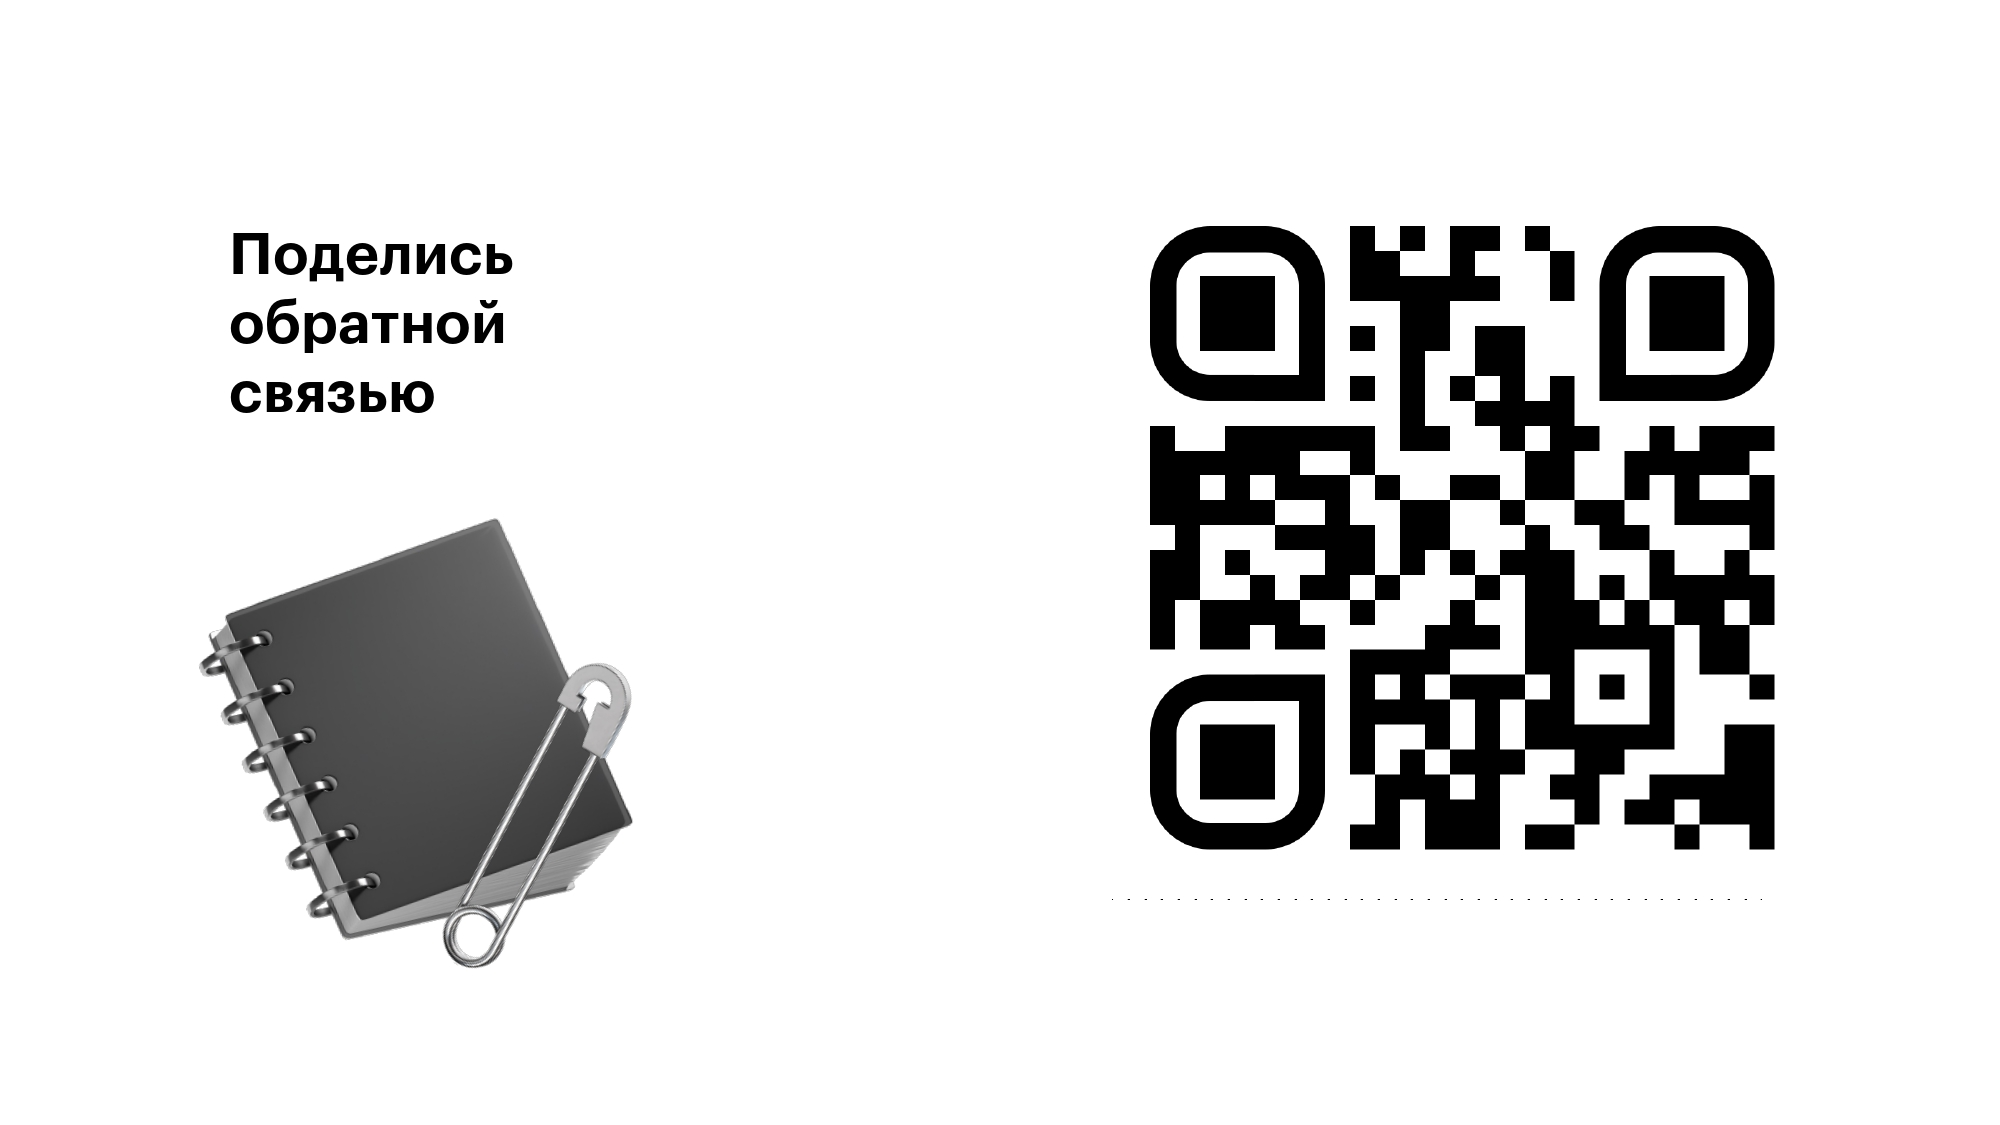